In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [14]:
#parametros del modelo
beta = 0.3
gamma = 0.1
n = 1000

In [15]:
#Condiciones iniciales
I0 = 10
R0 = 0
S0 = 990

In [17]:
#defininr ecuaciones diferenciales
def modelo_sir(y, t, beta, gamma, N):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

In [18]:
#tiempo de simlación
t = np.linspace(0,100,1000)

In [ ]:
#condiciones iniciales
y0 = [S0, I0, R0]

[990, 10, 0]

In [21]:
#resolver ecucaciones diferenciales
from scipy.integrate import odeint
solucion = odeint(modelo_sir, y0, t, args=(beta, gamma, n))

In [22]:
S, I , R = solucion.T

In [23]:
S, I, R

(array([990.        , 989.69979796, 989.39371385, 989.08163714,
        988.76345546, 988.43905455, 988.10831819, 987.77112823,
        987.42736452, 987.07690493, 986.71962528, 986.35539935,
        985.98409883, 985.60559333, 985.21975032, 984.82643514,
        984.42551095, 984.01683873, 983.60027723, 983.17568299,
        982.74291025, 982.30181101, 981.85223498, 981.39402951,
        980.92703963, 980.45110802, 979.96607498, 979.47177841,
        978.96805379, 978.45473418, 977.93165022, 977.39863004,
        976.85549932, 976.30208126, 975.73819658, 975.16366343,
        974.57829748, 973.98191185, 973.37431717, 972.75532147,
        972.12473024, 971.48234641, 970.82797037, 970.16139996,
        969.48243046, 968.79085458, 968.0864625 , 967.36904183,
        966.63837766, 965.89425255, 965.13644652, 964.36473711,
        963.57889937, 962.7787059 , 961.96392682, 961.13432982,
        960.28968021, 959.42974095, 958.55427263, 957.66303354,
        956.75577968, 955.83226486, 954.

In [24]:
# Encontrar el pico epidémico
indice_pico = np.argmax(I)
tiempo_pico = t[indice_pico]
infectados_max = I[indice_pico]

In [25]:
# Valores finales
recuperados_final = R[-1]
nunca_infectados = S[-1]

In [27]:
# Imprimir resultados
print(f"Pico epidémico en t = {tiempo_pico:.2f} días")
print(f"Infectados en el punto máximo = {infectados_max:.2f}")
print(f"Recuperados al final = {recuperados_final:.2f}")
print(f"Nunca se infectan = {nunca_infectados:.2f}")

Pico epidémico en t = 26.63 días
Infectados en el punto máximo = 303.81
Recuperados al final = 939.32
Nunca se infectan = 59.13


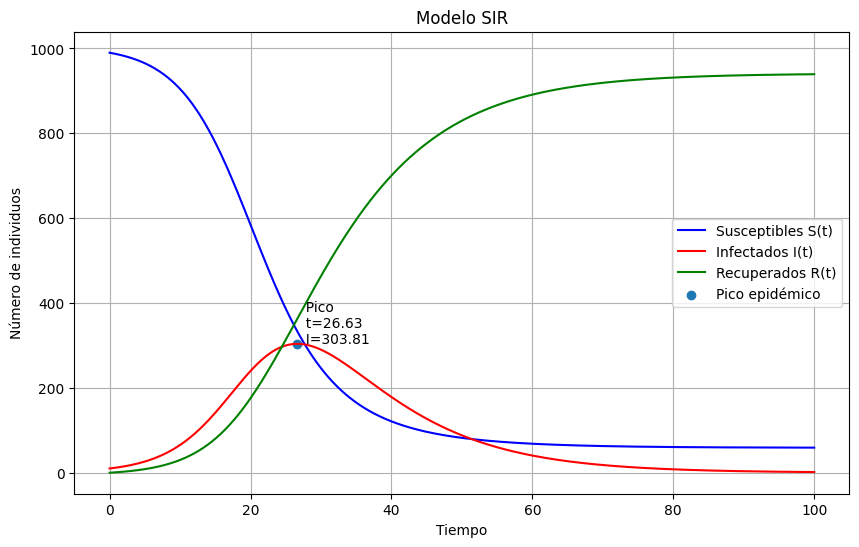

En el modelo SIR, la curva de infectados primero crece y después
disminuye debido a la interacción entre la tasa de contagio y la tasa de recuperación.



In [35]:
# Gráfica
plt.figure(figsize=(10, 6))
plt.plot(t, S, label='Susceptibles S(t)', color='blue')
plt.plot(t, I, label='Infectados I(t)', color= 'red')
plt.plot(t, R, label='Recuperados R(t)', color='green')

# Marcar el pico epidémico
plt.scatter(tiempo_pico, infectados_max, label='Pico epidémico')
plt.text(tiempo_pico, infectados_max,
         f'  Pico\n  t={tiempo_pico:.2f}\n  I={infectados_max:.2f}')

plt.title('Modelo SIR')
plt.xlabel('Tiempo')
plt.ylabel('Número de individuos')
plt.legend()
plt.grid(True)
plt.show()

print("En el modelo SIR, la curva de infectados primero crece y después")
print("disminuye debido a la interacción entre la tasa de contagio y la tasa de recuperación.\n")

In [ ]:
#Al inicio del brote epidémico la población tiene una gran cantidad de personas susceptibles y muy pocos infectados.
#Esto provoca que cada persona infectada tenga contacto con muchos susceptibles, lo que facilita la transmisión de la enfermedad. 
#Matemáticamente esto se representa en el término de contagio 𝛽 𝑆𝐼/𝑁, el cual es grande cuando 𝑆 es alto. 
#Por esta razón, el número de infectados aumenta rápidamente y la curva de infectados crece. Con el paso del tiempo ocurre 
#un cambio importante: cada vez hay menos personas susceptibles, porque muchas ya se infectaron. Al mismo tiempo, los infectados 
#comienzan a recuperarse a una tasa 𝛾. Cuando el número de susceptibles disminuye lo suficiente, la cantidad de nuevos contagios
#empieza a ser menor que la cantidad de personas que se recuperan. En ese momento se alcanza el pico epidémico. 
#Después del pico, el número de infectados comienza a disminuir porque cada vez hay menos personas susceptibles con las cuales 
#contagiarse y más personas pasan al grupo de recuperados. Finalmente, la epidemia se reduce hasta que prácticamente ya no quedan infectados.
#En resumen, la curva de infectados crece al inicio porque hay muchos susceptibles que pueden contagiarse, y disminuye después porque el 
#número de susceptibles se reduce y la recuperación de los infectados supera la aparición de nuevos casos.